# Task 3 — run 1 team metrics and failure candidates

Computes the team-format `metrics_report.csv` and the failure-case candidates for the **submitted model
(run 1, epoch 80)** from its saved checkpoint and saved predictions on Drive. **Nothing is retrained.**
Run 1's own notebook never computed these.

Same method as the team and the instructor's `Part3_Evaluation_Script.ipynb`: first 300 sorted images
per set, Inception-v3 (Resize 299 + CenterCrop 299). Direction names follow the team: A = Monet, B = photo,
so **A2B = Monet → photo** (my `outputs/pred_B2A`) and **B2A = photo → Monet** (my `outputs/pred_A2B`).

Writes (on Drive, under `task3_gan/shreya_akotiya/`):
- `metrics_report.csv` (team format, 30 columns; MiFID and KID std are printed)
- `outputs/failure_candidates.csv` and `outputs/plots/failure_candidates_{A2B,B2A}.jpg`

Use a **GPU runtime**, then *Runtime → Run all*. About 10–15 minutes.


In [1]:
import os, sys
from pathlib import Path


def lab1_root() -> Path:
    """Repo root, in priority order: LAB1_ROOT env var, the Drive copy on Colab,
    then a local clone found by walking up. Same convention as Tasks 1-2, so a
    run is relocatable instead of tied to one Drive account."""
    if os.environ.get("LAB1_ROOT"):
        return Path(os.environ["LAB1_ROOT"]).expanduser().resolve()
    if "google.colab" in sys.modules:
        from google.colab import drive
        drive.mount("/content/drive")
        return Path("/content/drive/MyDrive/DATA266_Lab1")
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if (cand / "task3_gan").is_dir() and (cand / "README.md").exists():
            return cand
    raise FileNotFoundError(
        "repo root not found - set LAB1_ROOT, e.g. "
        "os.environ['LAB1_ROOT'] = '/content/drive/MyDrive/DATA266_Lab1'")


ROOT = lab1_root()
os.environ["LAB1_ROOT"] = str(ROOT)       # child processes inherit it
print("LAB1_ROOT:", ROOT)

Mounted at /content/drive
LAB1_ROOT: /content/drive/MyDrive/DATA266_Lab1


In [2]:
!pip -q install lpips


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.4 MB/s eta 0:00:00


In [3]:
import math
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.linalg
import torch
import torch.nn as nn
import torchvision.models as tv_models
from PIL import Image, ImageDraw
from scipy.spatial.distance import cosine
from torchvision import transforms


In [4]:
ROOT = Path(os.environ["LAB1_ROOT"])   # resolved in the cell above
RUN_ID = "t3_shreya_unet_128_20261002_023102"
CKPT_NAME = f"{RUN_ID}_epoch080.pt"
TRAIN_HARDWARE = "NVIDIA A100-SXM4-40GB / cuda / torch 2.11.0+cu130"
N, NN_K, KID_SUBSET, KID_SUBSETS, SEED = 300, 5, 100, 50, 42
N_FAIL = 5
# run 1's submission, computed with the instructor's script (results.md) - used as a sanity check
EXPECTED_FID = {"A2B": 102.784, "B2A": 97.904}
LAMBDA_CYCLE, LAMBDA_IDENTITY = 10.0, 0.5
STEPS_PER_EPOCH, EPOCHS = 7038, 80


In [5]:
# ---- run 1 generator, copied from task3_cyclegan.ipynb (cells 17-18) ---------------------------

class UNetDown(nn.Module):
    def __init__(self, in_ch, out_ch, normalize=True, dropout=0.0):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 4, stride=2, padding=1, bias=False)]
        if normalize:
            layers.append(nn.InstanceNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class UNetUp(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1, bias=False),
                  nn.InstanceNorm2d(out_ch), nn.ReLU(inplace=True)]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip):
        return torch.cat([self.model(x), skip], dim=1)


class UNetGenerator(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, ngf=64, use_dropout=True):
        super().__init__()
        self.down1 = UNetDown(in_ch, ngf, normalize=False)
        self.down2 = UNetDown(ngf, ngf * 2)
        self.down3 = UNetDown(ngf * 2, ngf * 4)
        self.down4 = UNetDown(ngf * 4, ngf * 8)
        self.down5 = UNetDown(ngf * 8, ngf * 8)
        self.down6 = UNetDown(ngf * 8, ngf * 8)
        self.down7 = UNetDown(ngf * 8, ngf * 8, normalize=False)
        dropout = 0.5 if use_dropout else 0.0
        self.up1 = UNetUp(ngf * 8, ngf * 8, dropout=dropout)
        self.up2 = UNetUp(ngf * 16, ngf * 8, dropout=dropout)
        self.up3 = UNetUp(ngf * 16, ngf * 8, dropout=dropout)
        self.up4 = UNetUp(ngf * 16, ngf * 4)
        self.up5 = UNetUp(ngf * 8, ngf * 2)
        self.up6 = UNetUp(ngf * 4, ngf)
        self.final = nn.Sequential(nn.ConvTranspose2d(ngf * 2, out_ch, 4, stride=2, padding=1), nn.Tanh())

    def forward(self, x):
        d1 = self.down1(x); d2 = self.down2(d1); d3 = self.down3(d2); d4 = self.down4(d3)
        d5 = self.down5(d4); d6 = self.down6(d5); d7 = self.down7(d6)
        u1 = self.up1(d7, d6); u2 = self.up2(u1, d5); u3 = self.up3(u2, d4)
        u4 = self.up4(u3, d3); u5 = self.up5(u4, d2); u6 = self.up6(u5, d1)
        return self.final(u6)


In [6]:
# ---- metrics (same as the team's zoheb_waghu/evaluate_local.py) --------------------------------

INCEPTION_TF = transforms.Compose([
    transforms.Resize(299), transforms.CenterCrop(299), transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])
TEST_TF = transforms.Compose([   # run 1's test_transform
    transforms.Resize((256, 256), transforms.InterpolationMode.BICUBIC), transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])


def list_images(folder):
    return sorted(p for p in Path(folder).iterdir() if p.suffix.lower() in (".jpg", ".jpeg", ".png"))


def load(paths):
    return [Image.open(p).convert("RGB") for p in paths]


@torch.no_grad()
def inception_feats(model, images, device, bs=32):
    out = []
    for i in range(0, len(images), bs):
        x = torch.stack([INCEPTION_TF(im) for im in images[i:i + bs]]).to(device)
        out.append(model(x).cpu().numpy())
    return np.concatenate(out)


def frechet_distance(mu1, s1, mu2, s2, eps=1e-6):
    covmean = scipy.linalg.sqrtm(s1.dot(s2))
    if not np.isfinite(covmean).all():
        off = np.eye(s1.shape[0]) * eps
        covmean = scipy.linalg.sqrtm((s1 + off).dot(s2 + off))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    d = mu1 - mu2
    return float(d.dot(d) + np.trace(s1 + s2 - 2 * covmean))


def fid_mifid(real, gen):
    n = min(len(real), len(gen))
    real, gen = real[:n], gen[:n]
    fid = frechet_distance(real.mean(0), np.cov(real, rowvar=False), gen.mean(0), np.cov(gen, rowvar=False))
    return fid, float(np.mean([cosine(r, g) for r, g in zip(real, gen)]))


def kid(real, gen):
    rng = np.random.default_rng(SEED)
    m, d = min(KID_SUBSET, len(real), len(gen)), real.shape[1]
    vals = []
    for _ in range(KID_SUBSETS):
        x = real[rng.choice(len(real), m, replace=False)].astype(np.float64)
        y = gen[rng.choice(len(gen), m, replace=False)].astype(np.float64)
        a, b, c = (x @ x.T / d + 1) ** 3, (y @ y.T / d + 1) ** 3, (x @ y.T / d + 1) ** 3
        vals.append((a.sum() - np.trace(a) + b.sum() - np.trace(b)) / (m * (m - 1)) - 2 * c.mean())
    return float(np.mean(vals)), float(np.std(vals))


def prdc(real, gen, k=NN_K):
    r, g = torch.from_numpy(real), torch.from_numpy(gen)
    rad_r = torch.cdist(r, r).kthvalue(k + 1, dim=1).values
    rad_g = torch.cdist(g, g).kthvalue(k + 1, dim=1).values
    rg = torch.cdist(r, g)
    in_real = rg < rad_r[:, None]
    return {"gen_precision": in_real.any(0).float().mean().item(),
            "gen_recall": (rg < rad_g[None, :]).any(1).float().mean().item(),
            "density": in_real.sum(0).float().mean().item() / k,
            "coverage": (rg.min(1).values < rad_r).float().mean().item()}


def to_pil(t):
    t = (t.squeeze(0).cpu() * 0.5 + 0.5).clamp(0, 1)
    return Image.fromarray(t.mul(255).add(0.5).clamp(0, 255).permute(1, 2, 0).to(torch.uint8).numpy())


In [7]:
# ---- training stats from the checkpoint history and the raw log --------------------------------

def train_stats(history, log_path):
    tail = pd.DataFrame(history).tail(max(1, len(history["epoch"]) // 10))   # last 10% of training
    stats = {
        "gen_loss_final": tail.loss_G.mean(),
        "disc_loss_final": (tail.loss_D_A + tail.loss_D_B).mean(),
        "cycle_loss_final": ((tail.loss_cycle_A + tail.loss_cycle_B) / LAMBDA_CYCLE).mean(),
        "identity_loss_final": ((tail.loss_identity_A + tail.loss_identity_B) / (LAMBDA_CYCLE * LAMBDA_IDENTITY)).mean(),
        "grad_norm_mean": None,      # run 1 did not log gradient norms
        "peak_memory_gb": None,      # run 1 did not log peak memory
        "nan_count": None, "training_time_s": None, "images_per_sec": None,
    }
    if log_path.exists():
        text = log_path.read_text()
        losses = re.findall(r"Step \d+ \| G: (\S+) \| D_A: (\S+) \| D_B: (\S+) \| Cycle: (\S+)", text)
        stats["nan_count"] = sum(not all(math.isfinite(float(v)) for v in row) for row in losses)
        secs = [float(s) for s in re.findall(r"complete \| Time: ([\d.]+)s", text)]
        if len(secs) == EPOCHS:
            stats["training_time_s"] = sum(secs)
            stats["images_per_sec"] = STEPS_PER_EPOCH * EPOCHS / sum(secs)
        print(f"log: {len(losses)} logged steps, {stats['nan_count']} non-finite, {len(secs)} epoch times")
    else:
        print(f"WARNING: raw log not found at {log_path}; nan_count / training time left NOT_MEASURED")
    return stats


In [8]:
# ---- failure candidates grid -------------------------------------------------------------------

def failure_grid(rows, path):
    s, label_h = 256, 22
    grid = Image.new("RGB", (3 * s + 20, len(rows) * (s + label_h)), "white")
    draw = ImageDraw.Draw(grid)
    for i, r in enumerate(rows):
        y = i * (s + label_h)
        draw.text((4, y + 4), f"{i + 1}. {r['selected_as']} | {r['source_file']} | "
                              f"LPIPS {r['lpips']:.3f} | cycle L1 {r['cycle_l1']:.3f}", fill="black")
        for j, im in enumerate((r["_src"], r["_out"], r["_rec"])):
            grid.paste(im.resize((s, s)), (j * (s + 10), y + label_h))
    grid.save(path, quality=92)


In [9]:
def main(root=ROOT, n=N):

    member = root / "task3_gan" / "shreya_akotiya"
    data, out = root / "task3_gan" / "data", member / "outputs"
    ckpt_path = member / "checkpoints" / CKPT_NAME
    log_path = root / "reproducibility" / "raw_logs" / "shreya_akotiya" / "task3_gan" / f"{RUN_ID}.log"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(SEED)
    print(f"device: {device}\ncheckpoint: {ckpt_path}")

    ck = torch.load(ckpt_path, map_location=device, weights_only=False)
    assert ck["epoch"] == EPOCHS, f"expected the epoch-{EPOCHS} checkpoint, got epoch {ck['epoch']}"
    G_AB, G_BA = UNetGenerator().to(device), UNetGenerator().to(device)   # photo->Monet, Monet->photo
    G_AB.load_state_dict(ck["G_AB"]); G_BA.load_state_dict(ck["G_BA"])
    G_AB.eval(); G_BA.eval()
    n_params = sum(p.numel() for k in ("G_AB", "G_BA", "D_A", "D_B") for p in ck[k].values())

    inception = tv_models.inception_v3(weights=tv_models.Inception_V3_Weights.IMAGENET1K_V1, transform_input=False)
    inception.fc = nn.Identity()
    inception = inception.to(device).eval()
    import lpips
    lpips_fn = lpips.LPIPS(net="alex", verbose=False).to(device).eval()
    to_t = lambda im: (transforms.ToTensor()(im) * 2 - 1).unsqueeze(0).to(device)

    train = train_stats(ck["history"], log_path)
    train.update(parameter_count=n_params, hardware=TRAIN_HARDWARE)

    # (team name, real target set, source images, generated dir, forward G, backward G)
    directions = [("A2B", data / "photo_jpg", data / "monet_jpg", out / "pred_B2A", G_BA, G_AB),   # Monet -> photo
                  ("B2A", data / "monet_jpg", data / "photo_jpg", out / "pred_A2B", G_AB, G_BA)]   # photo -> Monet
    rows, extra, fail_rows = [], {}, []
    for name, target, src_dir, gen_dir, fwd, back in directions:
        gen_paths = list_images(gen_dir)[:n]
        srcs = {p.stem: p for p in list_images(src_dir)}
        pairs = [(srcs[g.stem], g) for g in gen_paths if g.stem in srcs]
        assert len(gen_paths) == n and len(pairs) == n, f"{name}: {len(gen_paths)} generated, {len(pairs)} pairs"

        real_f = inception_feats(inception, load(list_images(target)[:n]), device)
        gen_f = inception_feats(inception, load(gen_paths), device)
        fid, mifid = fid_mifid(real_f, gen_f)
        kid_mean, kid_std = kid(real_f, gen_f)
        src_f = inception_feats(inception, load([s for s, _ in pairs]), device)
        content_cos = (src_f * gen_f).sum(1) / (np.linalg.norm(src_f, axis=1) * np.linalg.norm(gen_f, axis=1))

        per = []
        with torch.no_grad():
            for (s, g) in pairs:
                src_im, out_im = Image.open(s).convert("RGB"), Image.open(g).convert("RGB")
                x = TEST_TF(src_im).unsqueeze(0).to(device)
                rec = back(fwd(x))
                per.append({"direction": name, "source_file": s.name,
                            "lpips": lpips_fn(to_t(src_im), to_t(out_im.resize(src_im.size))).item(),
                            "cycle_l1": ((rec - x).abs() / 2).mean().item(),   # [0, 1] pixel scale
                            "_src": src_im, "_out": out_im, "_rec": to_pil(rec)})

        row = {"direction": name, "run_id": RUN_ID, "checkpoint": CKPT_NAME, "fid": fid, "kid": kid_mean,
               **prdc(real_f, gen_f), "cycle_l1": float(np.mean([p["cycle_l1"] for p in per])),
               "lpips": float(np.mean([p["lpips"] for p in per])), "content_cosine": float(content_cos.mean()),
               **train}
        rows.append(row)
        extra[name] = {"mifid": mifid, "kid_std": kid_std}
        print(f"{name}: FID={fid:.3f} (submission: {EXPECTED_FID[name]}) MiFID={mifid:.4f} "
              f"KID={kid_mean:.5f}±{kid_std:.5f} P={row['gen_precision']:.3f} R={row['gen_recall']:.3f} "
              f"D={row['density']:.3f} C={row['coverage']:.3f} cycleL1={row['cycle_l1']:.4f} "
              f"LPIPS={row['lpips']:.4f} content_cos={row['content_cosine']:.4f}")
        if n == N and abs(fid - EXPECTED_FID[name]) > 0.5:
            print(f"WARNING: {name} FID differs from the submitted {EXPECTED_FID[name]} - "
                  f"check these are the same prediction files the submission used")

        # failure candidates: least changed, most changed, worst round trip
        by_lp = sorted(per, key=lambda p: p["lpips"])
        picks = ([dict(p, selected_as="least changed") for p in by_lp[:N_FAIL]]
                 + [dict(p, selected_as="most changed") for p in by_lp[::-1][:N_FAIL]]
                 + [dict(p, selected_as="worst cycle") for p in sorted(per, key=lambda p: -p["cycle_l1"])[:N_FAIL]])
        (out / "plots").mkdir(parents=True, exist_ok=True)
        failure_grid(picks, out / "plots" / f"failure_candidates_{name}.jpg")
        fail_rows += picks

    cols = ["direction", "run_id", "checkpoint", "fid", "kid", "gen_precision", "gen_recall", "density",
            "coverage", "cycle_l1", "lpips", "content_cosine", "gen_loss_final", "disc_loss_final",
            "cycle_loss_final", "identity_loss_final", "grad_norm_mean", "nan_count", "human_audit_style",
            "human_audit_content", "human_audit_artifacts", "inter_rater_kappa", "parameter_count",
            "training_time_s", "images_per_sec", "peak_memory_gb", "kaggle_public", "kaggle_private",
            "leaderboard_rank", "hardware"]
    team = pd.DataFrame(rows).reindex(columns=cols).round(5)
    team = team.astype(object).where(team.notna(), "NOT_MEASURED")   # human audit + Kaggle filled in by hand
    team.to_csv(member / "metrics_report.csv", index=False)

    pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in fail_rows]) \
        .round(5).to_csv(out / "failure_candidates.csv", index=False)
    print(f"\nWrote {member / 'metrics_report.csv'},\n"
          f"{out / 'failure_candidates.csv'} and {out / 'plots'}/failure_candidates_{{A2B,B2A}}.jpg")


## Run

**Check the printed FIDs:** they should match the submission (A2B 102.784, B2A 97.904) to within about 0.5.
A `WARNING: … FID differs` line means the prediction files on Drive are not the ones the submission used.


In [10]:
main()


device: cuda
checkpoint: /content/drive/MyDrive/DATA266_Lab1/task3_gan/shreya_akotiya/checkpoints/t3_shreya_unet_128_20261002_023102_epoch080.pt
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 178MB/s] 
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 122MB/s]


log: 11260 logged steps, 0 non-finite, 80 epoch times
A2B: FID=102.745 (submission: 102.784) MiFID=0.4206 KID=0.01848±0.00211 P=0.730 R=0.447 D=1.003 C=0.850 cycleL1=0.0223 LPIPS=0.2438 content_cos=0.8610
B2A: FID=97.852 (submission: 97.904) MiFID=0.4042 KID=0.00687±0.00128 P=0.540 R=0.730 D=0.492 C=0.767 cycleL1=0.0216 LPIPS=0.3043 content_cos=0.8215

Wrote /content/drive/MyDrive/DATA266_Lab1/task3_gan/shreya_akotiya/metrics_report.csv,
/content/drive/MyDrive/DATA266_Lab1/task3_gan/shreya_akotiya/outputs/failure_candidates.csv and /content/drive/MyDrive/DATA266_Lab1/task3_gan/shreya_akotiya/outputs/plots/failure_candidates_{A2B,B2A}.jpg


In [11]:
pd.read_csv(ROOT / "task3_gan/shreya_akotiya/metrics_report.csv").T


,0,1
direction,A2B,B2A
run_id,t3_shreya_unet_128_20261002_023102,t3_shreya_unet_128_20261002_023102
checkpoint,t3_shreya_unet_128_20261002_023102_epoch080.pt,t3_shreya_unet_128_20261002_023102_epoch080.pt
fid,102.74538,97.85232
kid,0.01848,0.00687
gen_precision,0.73,0.54
gen_recall,0.44667,0.73
density,1.00333,0.492
coverage,0.85,0.76667
cycle_l1,0.02229,0.02157


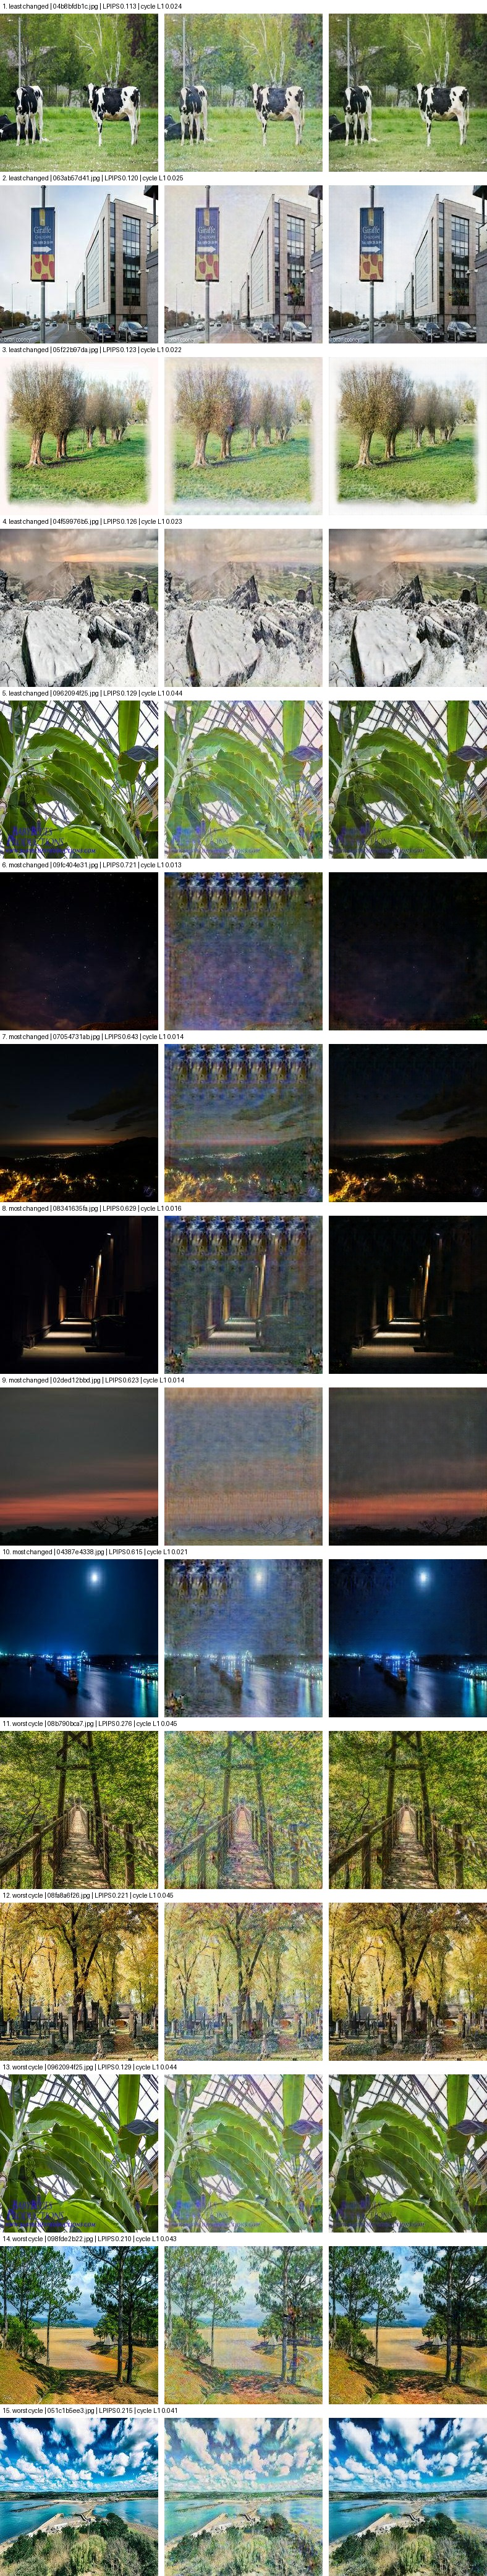

In [12]:
from IPython.display import Image as show
show(str(ROOT / "task3_gan/shreya_akotiya/outputs/plots/failure_candidates_B2A.jpg"), width=600)
